Laboratorio 6, Fisica Computacional

Juan Manuel Patiño


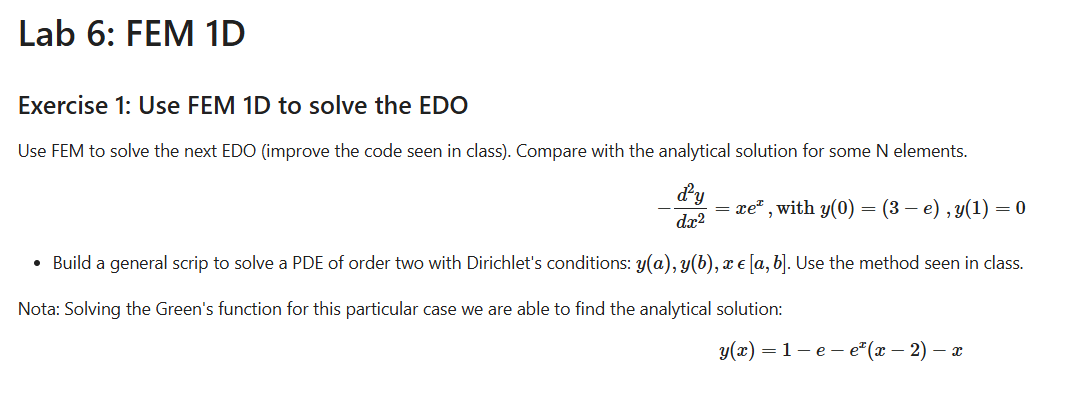

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [5]:
def exacta(x):
    return 1 - np.e + np.exp(x) * (2 - x) - x

def resolver_fem(N):
    h = 1.0 / N
    xi = np.linspace(0, 1, N + 1)

    # Matriz de rigidez global A
    A = np.zeros((N + 1, N + 1), float)
    A[0, 0] = 2 / h
    for i in range(1, N + 1):
        A[i, i] = 2 / h
        A[i, i - 1] = -1 / h
        A[i - 1, i] = -1 / h

    # Integración del término fuente con las funciones de forma
    def int1(x1, x2):
        return quad(lambda x: x * np.exp(x) * (x - x1) / h, x1, x2)[0]

    def int2(x1, x2):
        return quad(lambda x: x * np.exp(x) * (x2 - x) / h, x1, x2)[0]

    # Vector de carga b
    b = np.zeros(N + 1, float)
    for i in range(1, N + 1):
        b[i - 1] += int2(xi[i - 1], xi[i])
        b[i] += int1(xi[i - 1], xi[i])

    # Condiciones de frontera de Dirichlet
    Ua = 3 - np.e
    Ub = 0.0

    b[1] -= Ua * A[1, 0]
    b[N - 1] -= Ub * A[N - 1, N]

    b[0] = Ua
    b[N] = Ub

    A[0, 0] = 1; A[0, 1] = 0; A[1, 0] = 0
    A[N, N] = 1; A[N, N - 1] = 0; A[N - 1, N] = 0

    # Resolver el sistema A * u = b
    sol = np.linalg.solve(A, b)
    return xi, sol

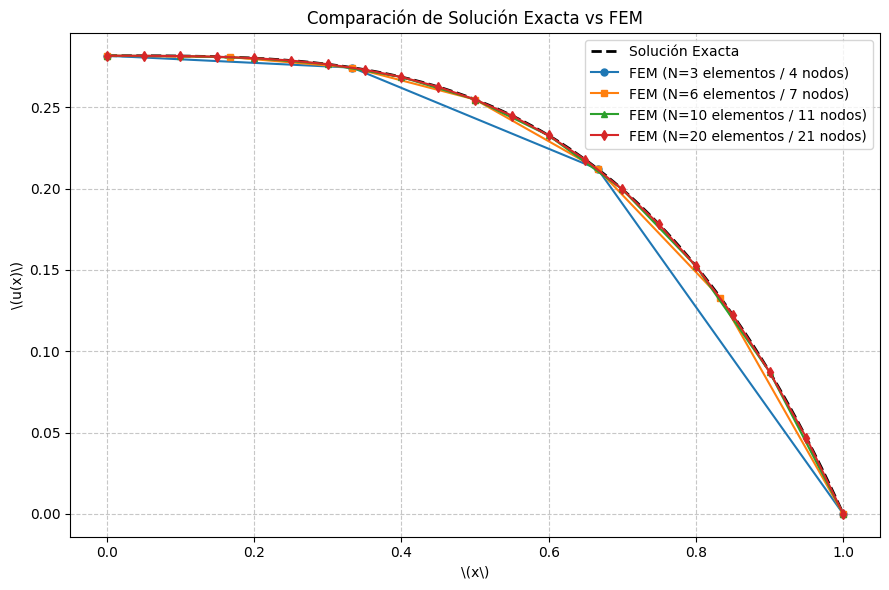

In [9]:
N = [3, 6, 10, 20]

xe = np.linspace(0, 1, 200)
ye = exacta(xe)

plt.figure(figsize=(9, 6))

# Graficar solucin exacta
plt.plot(xe, ye, 'k--', label='Solución Exacta', linewidth=2)

estilos = ['o-', 's-', '^-', 'd-']
for N, estilo in zip(N, estilos):
    xi, sol = resolver_fem(N)
    plt.plot(xi, sol, estilo, label=f'FEM (N={N} elementos / {N+1} nodos)', markersize=5)

plt.title('Comparación de Solución Exacta vs FEM')
plt.xlabel(r'\(x\)')
plt.ylabel(r'\(u(x)\)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.show()